<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 4</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Mohammad Reza Pirhadi <br>
        <b>🆔 Student ID:</b> 810102423 <br><br>
        <h5 style="color: #1a365d;"> TASK 1 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 4 - Task 1. It focuses on predicting median house prices using the California Housing dataset. The implementation covers a complete deep learning tabular workflow, including EDA, normalization, building a <b>Multi-Layer Perceptron (MLP)</b>, and evaluating the impact of manual feature engineering.
</div>

## Table of Contents
1. [Exploratory Data Analysis (EDA)](#exploration)
2. [Data Preparation & Feature Engineering](#preprocessing)
3. [Model Development & Training](#modeling)
4. [Evaluation & Error Analysis](#evaluation)

In [522]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import random
import os

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

In [ ]:

def set_deterministic(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_deterministic(42)

Random seed set to 42


In [524]:
df = pd.read_csv('california_housing.csv')

missing_count = df.isnull().sum()
print("Missing values in each column:\n", missing_count[missing_count > 0])

if missing_count.sum() > 0:
    print("\nHandling missing values using Mean Imputation...")
    imputer = SimpleImputer(strategy='mean') 
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
else:
    df_imputed = df

y = df_imputed['MedHouseVal']
X = df_imputed.drop(columns=['MedHouseVal'])

print("Data is clean and ready.")
print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
display(X.head())

Missing values in each column:
 Series([], dtype: int64)
Data is clean and ready.
Dataset Shape: (20640, 8)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


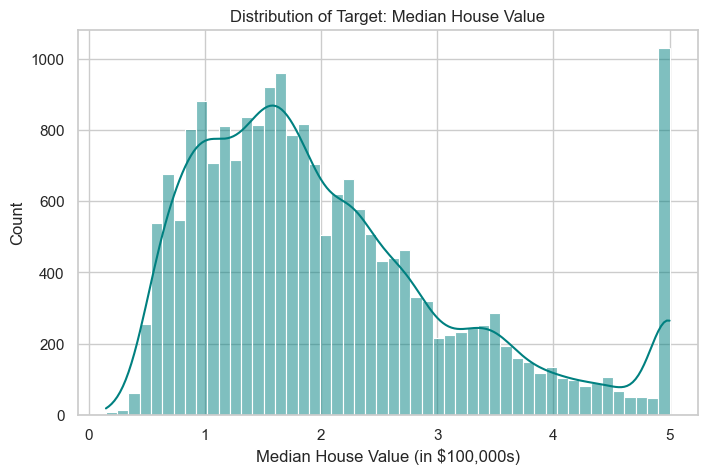

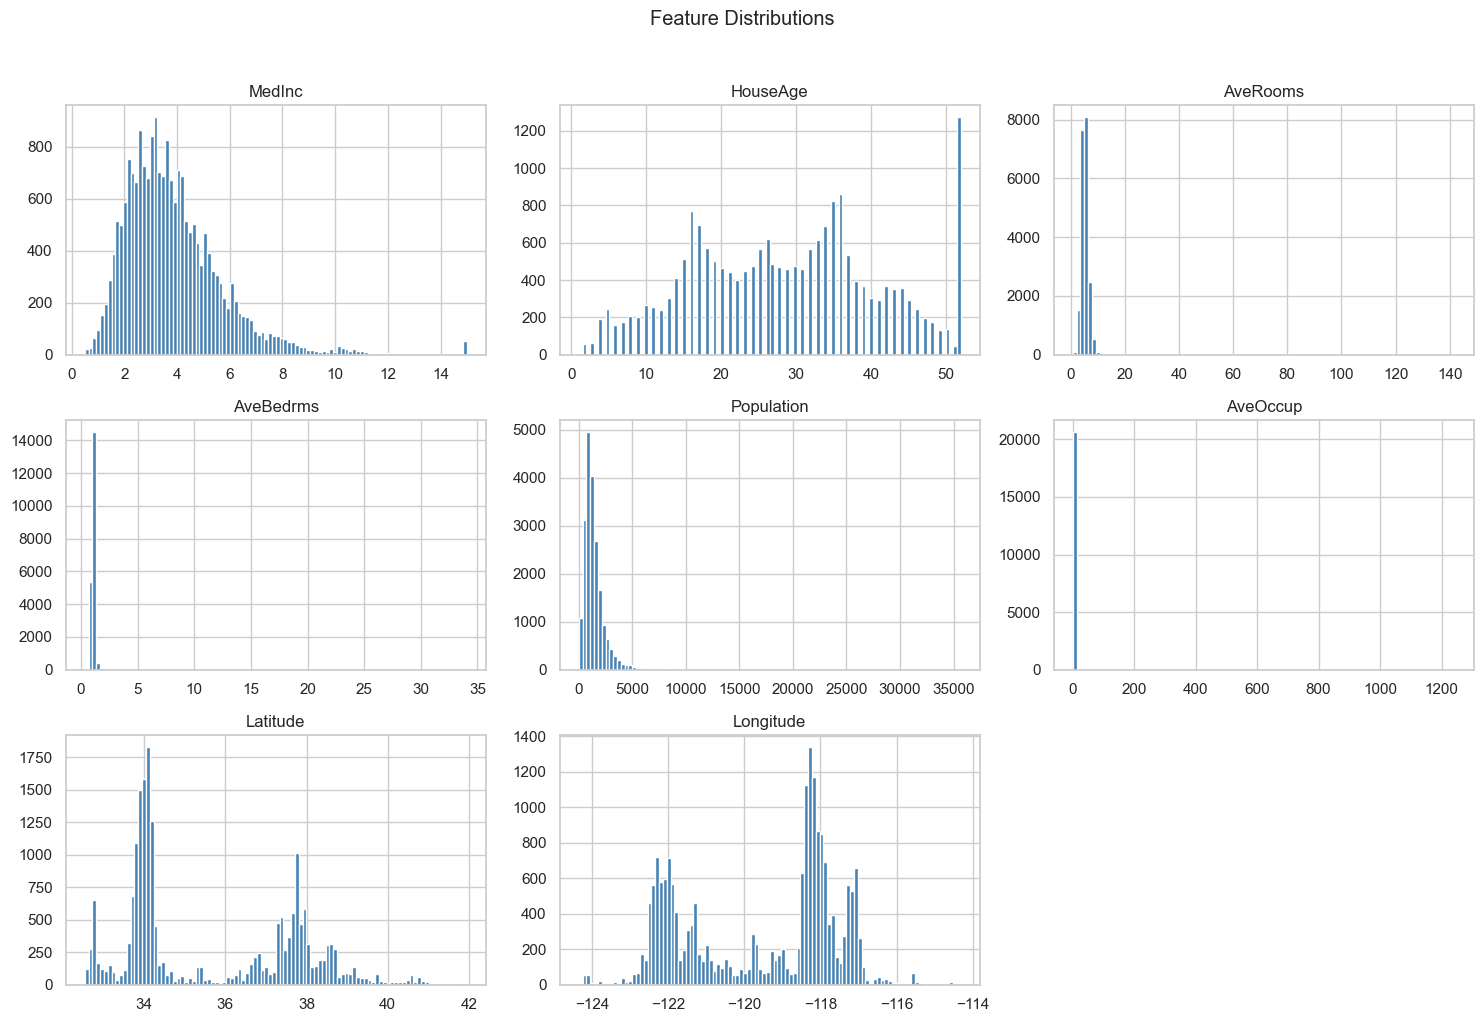

In [525]:

print("Dataset Information:")
print(X.info())
print("\nStatistical Summary:")
display(X.describe())

plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True, color='teal')
plt.title('Distribution of Target: Median House Value')
plt.xlabel('Median House Value (in $100,000s)')
plt.show()

X.hist(bins=100, figsize=(15, 10), color='steelblue')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

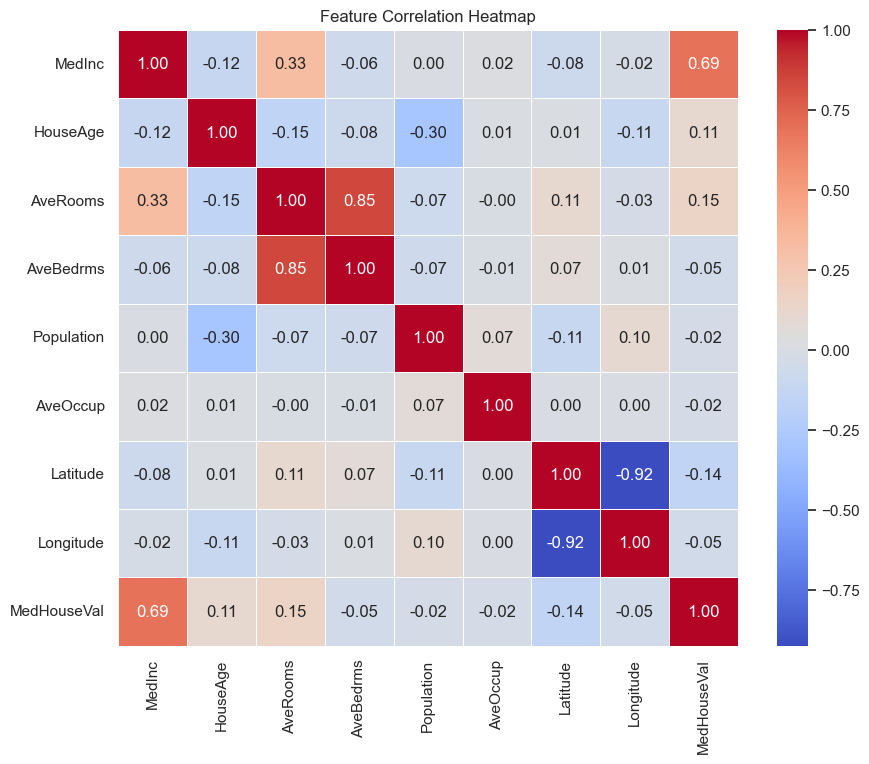

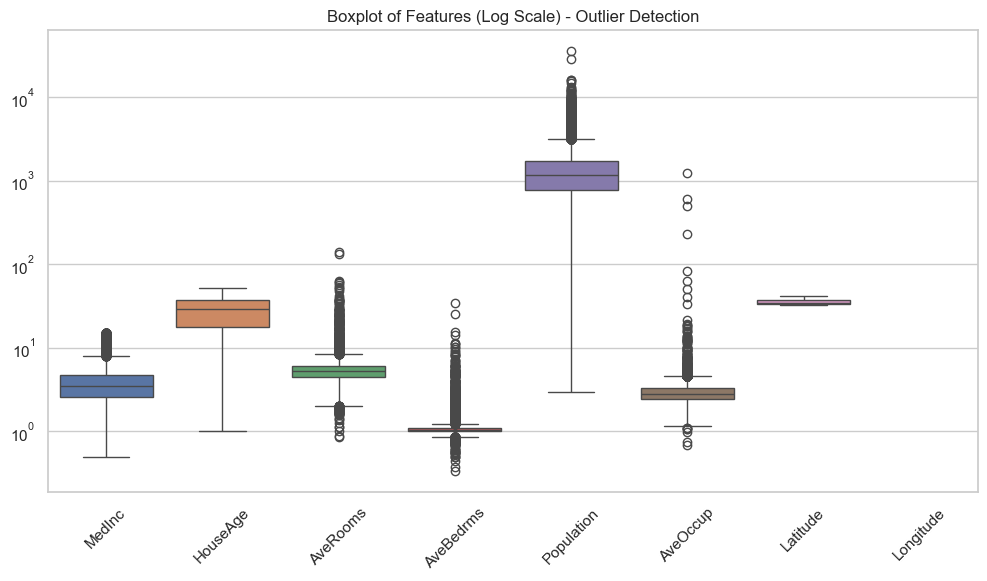

In [526]:
full_data = pd.concat([X, y], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(full_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=X)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Boxplot of Features (Log Scale) - Outlier Detection')
plt.show()

In [527]:
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

def create_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=64):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)
    X_v_t = torch.tensor(X_v, dtype=torch.float32)
    y_v_t = torch.tensor(y_v.values, dtype=torch.float32).view(-1, 1)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te.values, dtype=torch.float32).view(-1, 1)
    
    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_v_t, y_v_t), batch_size=batch_size)
    test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=batch_size)
    
    return train_loader, val_loader, test_loader, X_te_t, y_te_t

train_loader_base, val_loader_base, test_loader_base, X_test_base, y_test_t = create_dataloaders(
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
)
print("Data Loaders Created Successfully.")

Data Loaders Created Successfully.


In [528]:
class EarlyStopping:
    def __init__(self, patience=15): 
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super(RegressionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.network(x)


Training Baseline Model...
Early stopping triggered at epoch 119


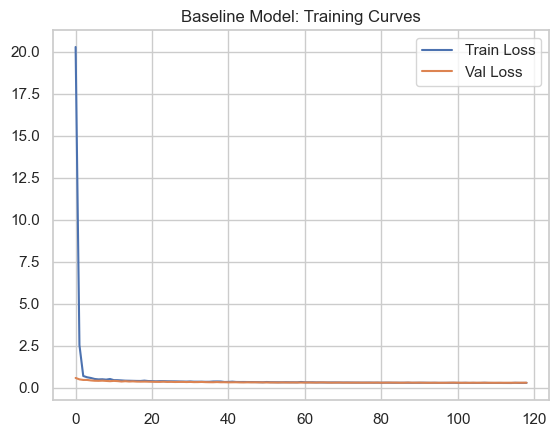

In [529]:
def train_model(model, train_loader, val_loader, epochs=150, lr=0.001, patience=15):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=patience)
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
                
        val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)
        
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    model.load_state_dict(early_stopping.best_state)
    return model, train_losses, val_losses



print("Training Baseline Model...")
baseline_model = RegressionMLP(input_dim=X_train_scaled.shape[1])
baseline_model, b_train_loss, b_val_loss = train_model(baseline_model, train_loader_base, val_loader_base)

plt.plot(b_train_loss, label='Train Loss')
plt.plot(b_val_loss, label='Val Loss')
plt.title('Baseline Model: Training Curves')
plt.legend()
plt.show()

In [530]:
def clean_and_engineer(df, target):
    data = df.copy()
    data['Target'] = target
    
    mask = (data['AveRooms'] <= 10) & (data['AveOccup'] <= 6) & (data['AveBedrms'] <= 4)  & (data['Population'] <= 6800) 
    data_clean = data[mask].copy()
    
    sf_lat, sf_lon = 37.77, -122.41
    la_lat, la_lon = 34.05, -118.24
    
    data_clean['Dist_to_SF'] = np.sqrt((data_clean['Latitude'] - sf_lat)**2 + (data_clean['Longitude'] - sf_lon)**2)
    data_clean['Dist_to_LA'] = np.sqrt((data_clean['Latitude'] - la_lat)**2 + (data_clean['Longitude'] - la_lon)**2)
    
    
    data_clean['RoomsPerHousehold'] = data_clean['AveRooms'] / (data_clean['AveOccup'] + 1e-6)
    data_clean['BedroomsPerRoom'] = data_clean['AveBedrms'] / (data_clean['AveRooms'] + 1e-6)
    data_clean['PopPerHouse'] = data_clean['Population'] / (data_clean['AveOccup'] + 1e-6)

    data_clean['Dist_to_SF_log'] = np.log1p(data_clean['Dist_to_SF'])
    data_clean['Dist_to_LA_log'] = np.log1p(data_clean['Dist_to_LA'])
    
    columns_to_drop = [ 'Population']
    data_clean = data_clean.drop(columns=columns_to_drop)

    y_final = data_clean['Target']
    X_final = data_clean.drop(columns=['Target'])
    
    return X_final, y_final

X_clean, y_clean = clean_and_engineer(X, y)
print(f"Original Shape: {X.shape}")
print(f"Cleaned Shape: {X_clean.shape} (Removed {(X.shape[0] - X_clean.shape[0])} garbage rows)")

correlations = X_clean.corrwith(y_clean)
print(correlations.sort_values(ascending=False))

Original Shape: (20640, 8)
Cleaned Shape: (20175, 14) (Removed 465 garbage rows)
MedInc               0.690297
RoomsPerHousehold    0.439608
AveRooms             0.329174
HouseAge             0.108105
PopPerHouse          0.071000
Dist_to_SF          -0.041583
Longitude           -0.046223
Dist_to_SF_log      -0.098453
AveBedrms           -0.101490
Dist_to_LA          -0.114972
Dist_to_LA_log      -0.138426
Latitude            -0.142537
BedroomsPerRoom     -0.254903
AveOccup            -0.283466
dtype: float64


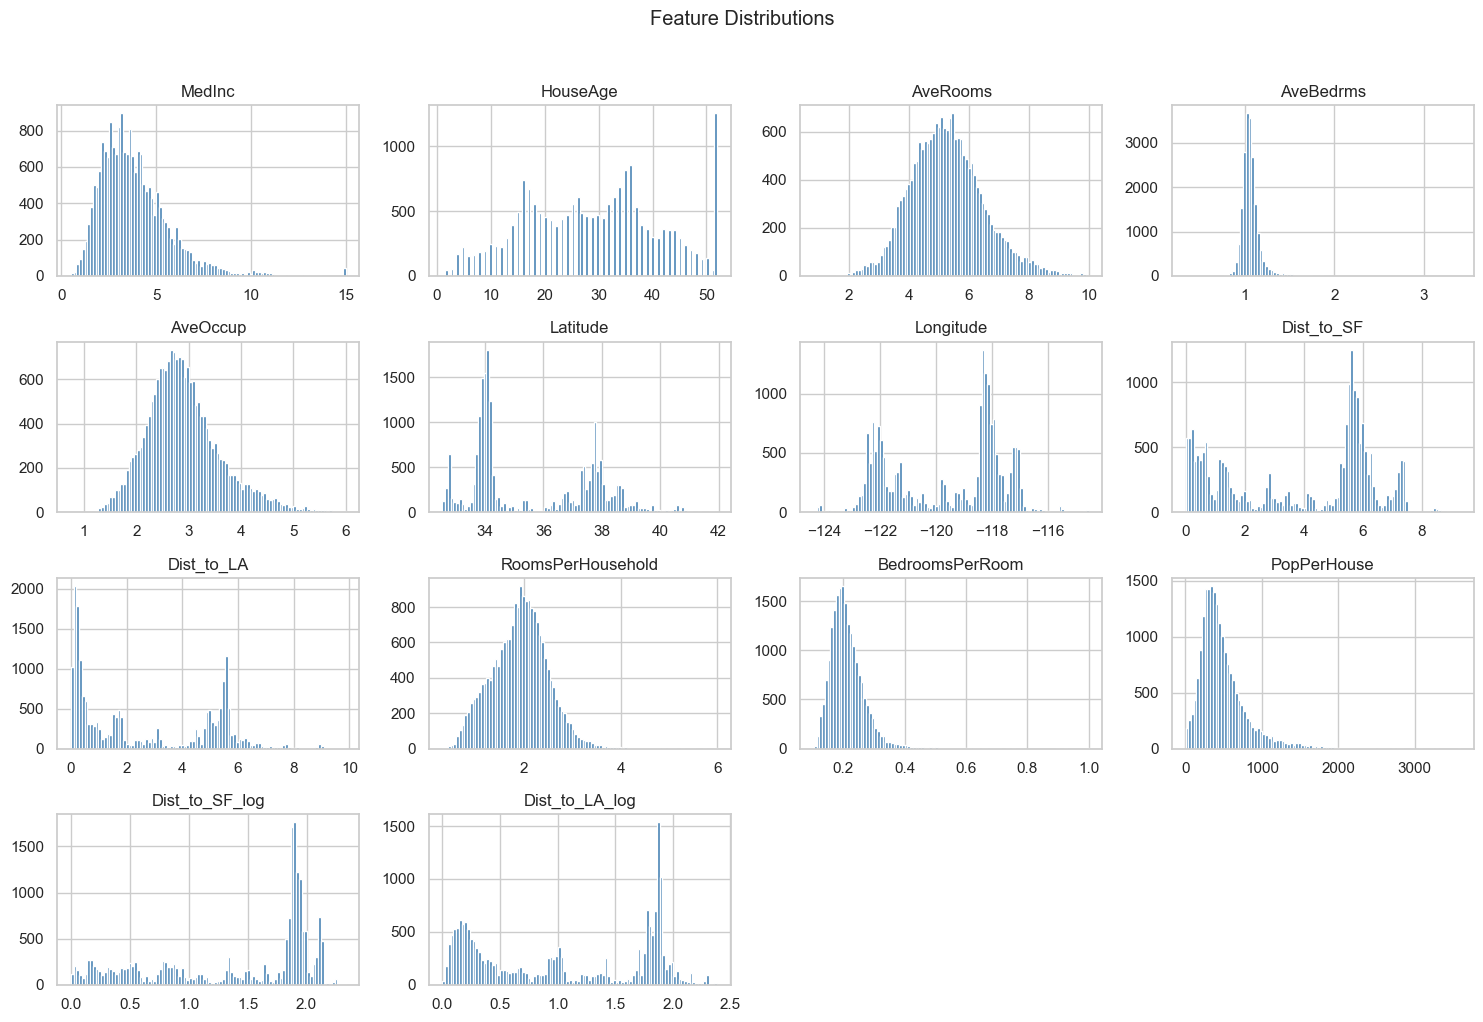

In [536]:
X_clean.hist(bins=100, figsize=(15, 10), color='steelblue')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [531]:
X_train_eng_raw, X_temp_eng, y_train_eng, y_temp_eng = train_test_split(
    X_clean, y_clean, test_size=0.30, random_state=42
)
X_val_eng_raw, X_test_eng_raw, y_val_eng, y_test_eng = train_test_split(
    X_temp_eng, y_temp_eng, test_size=0.50, random_state=42
)

scaler_eng = RobustScaler() 
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng_raw)
X_val_eng_scaled = scaler_eng.transform(X_val_eng_raw)
X_test_eng_scaled = scaler_eng.transform(X_test_eng_raw)

train_loader_eng, val_loader_eng, test_loader_eng, X_test_eng, y_test_eng_t = create_dataloaders(
    X_train_eng_scaled, y_train_eng, X_val_eng_scaled, y_val_eng, X_test_eng_scaled, y_test_eng
)
print("Enhanced Data Loaders Created Successfully with Cleaned Data.")

Enhanced Data Loaders Created Successfully with Cleaned Data.


Training Enhanced Model on Cleaned Data...
Early stopping triggered at epoch 119


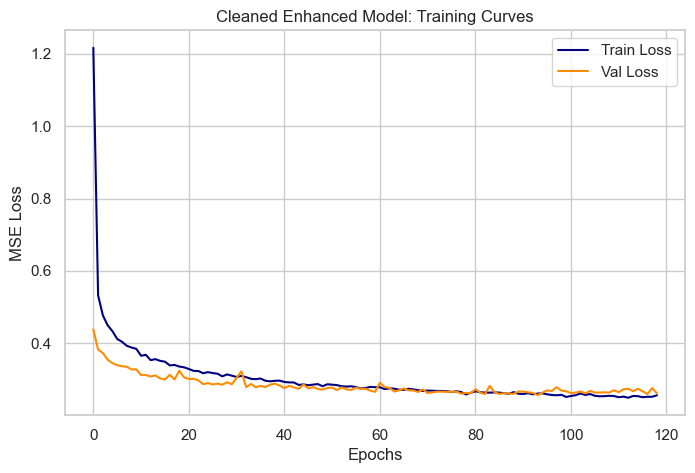

In [532]:
print("Training Enhanced Model on Cleaned Data...")

enhanced_model = RegressionMLP(input_dim=X_train_eng_scaled.shape[1])

enhanced_model, e_train_loss, e_val_loss = train_model(
    enhanced_model, 
    train_loader_eng, 
    val_loader_eng, 
    epochs=150, 
    lr=0.0008,  
    patience=25 
)

plt.figure(figsize=(8, 5))
plt.plot(e_train_loss, label='Train Loss', color='navy')
plt.plot(e_val_loss, label='Val Loss', color='darkorange')
plt.title('Cleaned Enhanced Model: Training Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [533]:
def evaluate_and_predict(model, X_test_tensor, y_test_tensor, model_name):
    model.eval() 
    with torch.no_grad():
        preds = model(X_test_tensor).numpy()
    
    y_true = y_test_tensor.numpy()
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    
    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")
    
    return preds, y_true


In [534]:

preds_base, y_true_base = evaluate_and_predict(
    baseline_model, X_test_base, y_test_t, "Baseline Model"
)

preds_eng, y_true_eng = evaluate_and_predict(
    enhanced_model, X_test_eng, y_test_eng_t, "Enhanced Model"
)

--- Baseline Model Performance ---
MAE:  0.3472
RMSE: 0.4983
R2 Score: 0.8122

--- Enhanced Model Performance ---
MAE:  0.3340
RMSE: 0.4798
R2 Score: 0.8358



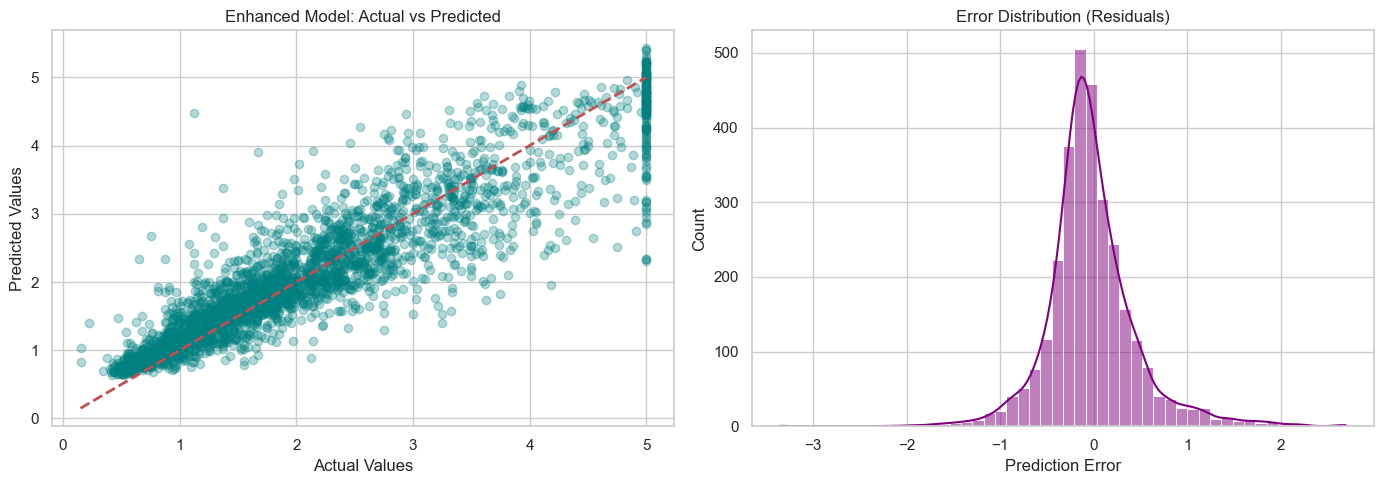

Top 5 Largest Prediction Errors:


,Actual,Predicted,Error
2733,1.12500,4.476737,-3.351737
1852,5.00001,2.307872,2.692138
1615,5.00001,2.340610,2.659400
1364,5.00001,2.344795,2.655215
1137,1.67000,3.903981,-2.233981
...,...,...,...
545,2.79600,2.796712,-0.000712
1632,1.44300,1.442415,0.000585
1074,1.65200,1.651446,0.000554
2255,2.02300,2.023309,-0.000309


In [535]:

errors = y_true_eng.flatten() - preds_eng.flatten()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(y_true_eng, preds_eng, alpha=0.3, color='teal')
axs[0].plot([y_true_eng.min(), y_true_eng.max()], [y_true_eng.min(), y_true_eng.max()], 'r--', lw=2)
axs[0].set_title('Enhanced Model: Actual vs Predicted')
axs[0].set_xlabel('Actual Values')
axs[0].set_ylabel('Predicted Values')

sns.histplot(errors, bins=50, kde=True, ax=axs[1], color='purple')
axs[1].set_title('Error Distribution (Residuals)')
axs[1].set_xlabel('Prediction Error')

plt.tight_layout()
plt.show()

error_df = pd.DataFrame({'Actual': y_true_eng.flatten(), 'Predicted': preds_eng.flatten(), 'Error': errors})
print("Top 5 Largest Prediction Errors:")
display(error_df.reindex(error_df['Error'].abs().sort_values(ascending=False).index))

### Task 1 - Question: Equivalence of MLP and Logistic Regression

**Question:** Under what conditions is an MLP mathematically equivalent to Logistic Regression?

**Answer & Mathematical Analysis:**
A Multi-Layer Perceptron (MLP) becomes mathematically identical to a standard Binary Logistic Regression model when the following strict architectural and functional conditions are met simultaneously:

1. **Zero Hidden Layers (Direct Connection):** The network must have absolutely no hidden layers. The input layer (features) must connect directly to the output layer via a single linear transformation (weights and bias). This removes the deep, non-linear feature extraction capability of the MLP.
2. **Single Output Node:** For binary classification, the output layer must consist of exactly one neuron.
3. **Sigmoid Activation Function:** The output neuron must utilize the Sigmoid (Logistic) activation function. This squashes the linear combination of inputs into a probability bounded between 0 and 1.
4. **Log-Loss (Binary Cross-Entropy):** The network must be optimized using the Binary Cross-Entropy loss function, which corresponds exactly to maximizing the log-likelihood in Logistic Regression.

**Mathematical Proof:**
When an MLP is configured with zero hidden layers, an input vector $X$, a weight vector $W$, and a bias term $b$, the forward pass equation is simply:

$$z = W^T X + b$$

Applying the required Sigmoid activation function $\sigma(z) = \frac{1}{1 + e^{-z}}$ to this linear output yields:

$$\hat{y} = \frac{1}{1 + e^{-(W^T X + b)}}$$

This is the exact mathematical formulation of Logistic Regression. Therefore, a 0-hidden-layer MLP with a sigmoid output and BCE loss is merely executing Logistic Regression via gradient descent.